# Proyecto 1 — EDA
### CC3092 Deep Learning y Sistemas Inteligentes

**Dataset:** *Ames Housing* — predicción del precio de venta de casas (`SalePrice`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

df = pd.read_csv("../train.csv")
print("Dimensiones (filas, columnas):", df.shape)
df.head()

Dimensiones (filas, columnas): (1168, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1957,1957,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,Gd,CBlock,TA,TA,No,Rec,922,Unf,0,392,1314,GasA,TA,Y,SBrkr,1314,0,0,1314,1,0,1,0,3,1,TA,5,Typ,0,NaN,Attchd,1957.0,RFn,1,294,TA,TA,Y,250,0,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,7,1993,1994,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,799,799,GasA,Gd,Y,SBrkr,799,772,0,1571,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1993.0,RFn,2,380,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Feedr,Norm,1Fam,1Story,5,7,1910,1950,Gable,CompShg,MetalSd,'Wd Sdng',NaN,0.0,TA,TA,CBlock,Fa,TA,No,Unf,0,Unf,0,796,796,GasA,Gd,Y,FuseA,796,0,0,796,0,0,1,0,2,1,TA,4,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,P,328,0,164,0,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,SWISU,Feedr,Norm,1Fam,1.5Fin,5,7,1937,1950,Gable,CompShg,'Wd Sdng','Wd Sdng',BrkFace,252.0,TA,TA,BrkTil,Gd,TA,No,ALQ,569,Unf,0,162,731,GasA,Ex,Y,SBrkr,981,787,0,1768,1,0,1,1,3,1,Gd,7,Typ,2,TA,Detchd,1939.0,Unf,1,240,TA,TA,Y,0,0,264,0,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Norm,Norm,1Fam,1.5Fin,5,6,1924,1950,Gable,CompShg,BrkFace,'Wd Sdng',NaN,0.0,TA,TA,BrkTil,TA,TA,No,LwQ,218,Unf,0,808,1026,GasA,TA,Y,SBrkr,1026,665,0,1691,0,0,2,0,3,1,Gd,6,Typ,1,Gd,Detchd,1924.0,Unf,1,308,TA,TA,Y,0,0,242,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


## 1. Dimensiones y tipos de variables

El dataset de entrenamiento tiene **1168 observaciones** y **81 columnas**: `Id`, la variable
objetivo `SalePrice`, y **79 features**.

In [ ]:
# Tipos
print("Conteo de dtypes:")
print(df.dtypes.value_counts(), "\n")

id_col = "Id"
target = "SalePrice"

num_cols = df.select_dtypes(include=[np.number]).drop(columns=[id_col, target]).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print(f"# columnas numéricas (sin Id ni target): {len(num_cols)}")
print(f"# columnas categóricas (object):         {len(cat_cols)}")

Conteo de dtypes:
object     43
int64      35
float64     3
Name: count, dtype: int64 

# columnas numéricas (sin Id ni target): 36
# columnas categóricas (object):         43


In [ ]:
pseudo_categoricas = ["MSSubClass", "OverallQual", "OverallCond", "MoSold"]
df[pseudo_categoricas].describe().T[["min", "max", "mean"]]

,min,max,mean
MSSubClass,20.0,190.0,56.849315
OverallQual,1.0,10.0,6.121575
OverallCond,1.0,9.0,5.584760
MoSold,1.0,12.0,6.356164


### Variable objetivo: `SalePrice`

Es continua y **positiva**.

count      1168.0
mean     181442.0
std       77264.0
min       34900.0
25%      130000.0
50%      165000.0
75%      214925.0
max      745000.0
Name: SalePrice, dtype: float64

Asimetría (skew) SalePrice     : 1.743
Asimetría (skew) log1p(SalePrice): 0.125


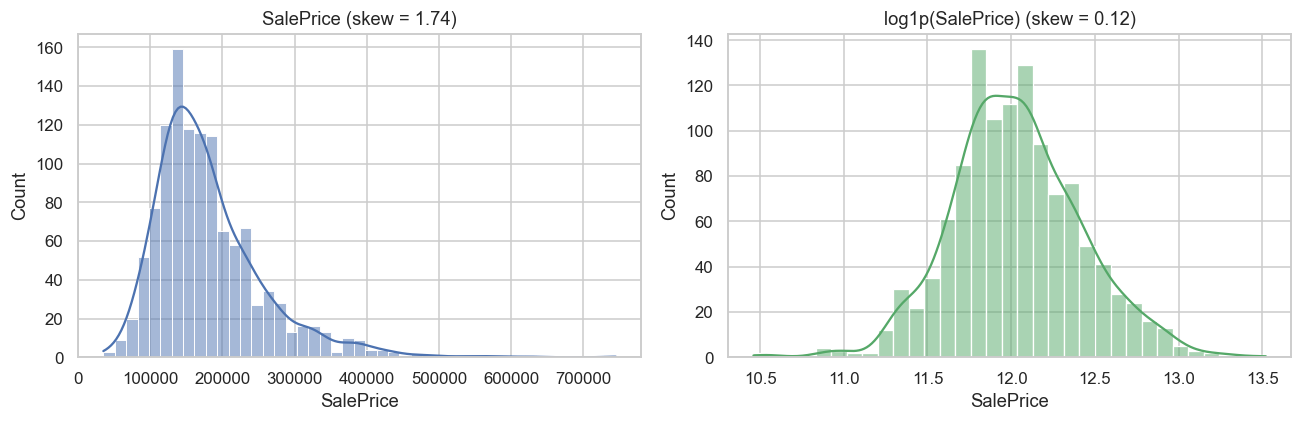

In [4]:
desc = df[target].describe()
print(desc.round(0))
print("\nAsimetría (skew) SalePrice     :", round(df[target].skew(), 3))
print("Asimetría (skew) log1p(SalePrice):", round(np.log1p(df[target]).skew(), 3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[target], kde=True, ax=ax[0], color="#4C72B0")
ax[0].set_title(f"SalePrice (skew = {df[target].skew():.2f})")
sns.histplot(np.log1p(df[target]), kde=True, ax=ax[1], color="#55A868")
ax[1].set_title(f"log1p(SalePrice) (skew = {np.log1p(df[target]).skew():.2f})")
plt.tight_layout(); plt.show()

**Decisión 1 — Transformación del target.**
`SalePrice` tiene asimetría **1.74** (cola derecha larga: casas muy caras). Al aplicar
`log1p` la asimetría cae a **0.13**, quedando casi simétrica. Por eso:

- Entrenar el MLP para predecir **`log1p(SalePrice)`** y luego invertiremos con `expm1`.

## 2. Estadísticas descriptivas de variables relevantes

In [5]:
rel = ["OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF",
       "1stFlrSF", "FullBath", "YearBuilt", "YearRemodAdd", "LotArea", target]
df[rel].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
OverallQual,1168.0,6.1,1.4,1.0,5.0,6.0,7.0,10.0
GrLivArea,1168.0,1527.4,524.4,334.0,1145.8,1473.0,1792.0,5642.0
GarageCars,1168.0,1.8,0.7,0.0,1.0,2.0,2.0,4.0
GarageArea,1168.0,476.3,211.1,0.0,341.0,482.0,576.0,1418.0
TotalBsmtSF,1168.0,1061.8,440.7,0.0,796.0,997.5,1299.2,6110.0
1stFlrSF,1168.0,1169.4,386.7,334.0,888.0,1095.0,1396.8,4692.0
FullBath,1168.0,1.6,0.5,0.0,1.0,2.0,2.0,3.0
YearBuilt,1168.0,1971.0,30.7,1872.0,1953.0,1972.0,2001.0,2010.0
YearRemodAdd,1168.0,1984.9,20.7,1950.0,1966.0,1994.0,2004.0,2010.0
LotArea,1168.0,10689.6,10759.4,1300.0,7587.2,9600.0,11700.0,215245.0


## 3. Valores nulos, atípicos e inconsistencias

### 3.1 Valores nulos

              n_nulos   pct
PoolQC           1162  99.5
MiscFeature      1122  96.1
Alley            1094  93.7
Fence             935  80.1
MasVnrType        683  58.5
FireplaceQu       547  46.8
LotFrontage       217  18.6
GarageType         64   5.5
GarageYrBlt        64   5.5
GarageFinish       64   5.5
GarageQual         64   5.5
GarageCond         64   5.5
BsmtFinType1       28   2.4
BsmtFinType2       28   2.4
BsmtExposure       28   2.4
BsmtCond           28   2.4
BsmtQual           28   2.4
MasVnrArea          6   0.5
Electrical          1   0.1


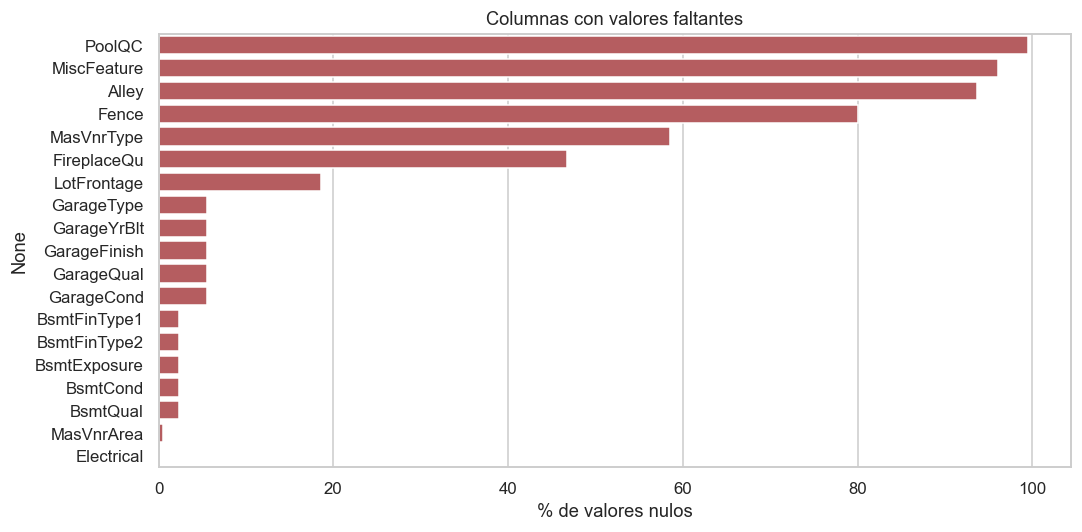

In [6]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
null_tbl = pd.DataFrame({"n_nulos": nulls, "pct": (nulls / len(df) * 100).round(1)})
print(null_tbl.to_string())

plt.figure(figsize=(10, 5))
sns.barplot(x=null_tbl["pct"], y=null_tbl.index, color="#C44E52")
plt.xlabel("% de valores nulos"); plt.title("Columnas con valores faltantes")
plt.tight_layout(); plt.show()

En este dataset, en la mayoría de las columnas el `NaN` **significa ausencia de la característica**,
no un error de captura. Según la documentación de Ames:

| Columna(s) | Qué significa el NaN |
|---|---|
| `PoolQC` (99.5%) | La casa **no tiene pileta** |
| `MiscFeature` (96%), `Alley` (94%), `Fence` (80%) | No tiene ese elemento |
| `FireplaceQu` (47%) | No tiene chimenea |
| `Garage*` (5.5%) | No tiene garaje |
| `Bsmt*` (2.4%) | No tiene sótano |

Estos se imputan con la categoría **`"None"`** (o `0` en las numéricas asociadas), **no** se eliminan.

Faltantes que sí son "reales" y requieren imputación estadística:
- **`LotFrontage` (18.6%)**: metros lineales de frente de lote → imputar por **mediana del barrio** (`Neighborhood`), ya que lotes del mismo barrio se parecen.
- **`MasVnrArea` (0.5%) / `MasVnrType`**: imputar `0` / `"None"`.
- **`Electrical` (1 fila)**: imputar con la **moda**.

In [7]:
# Columnas donde NaN = "None" (ausencia de la característica)
none_cols = ["PoolQC","MiscFeature","Alley","Fence","FireplaceQu","GarageType","GarageFinish",
             "GarageQual","GarageCond","BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1",
             "BsmtFinType2","MasVnrType"]
faltan_reales = [c for c in df.columns if df[c].isnull().any() and c not in none_cols]
print("Columnas con NaN = 'None' (ausencia):", len(none_cols))
print("Faltantes 'reales' a imputar por estadística:", faltan_reales)

Columnas con NaN = 'None' (ausencia): 15
Faltantes 'reales' a imputar por estadística: ['LotFrontage', 'MasVnrArea', 'Electrical', 'GarageYrBlt']


### 3.2 Valores atípicos (outliers)

El autor del dataset recomienda remover viviendas con
`GrLivArea > 4000` porque incluyen ventas parciales/atípicas.

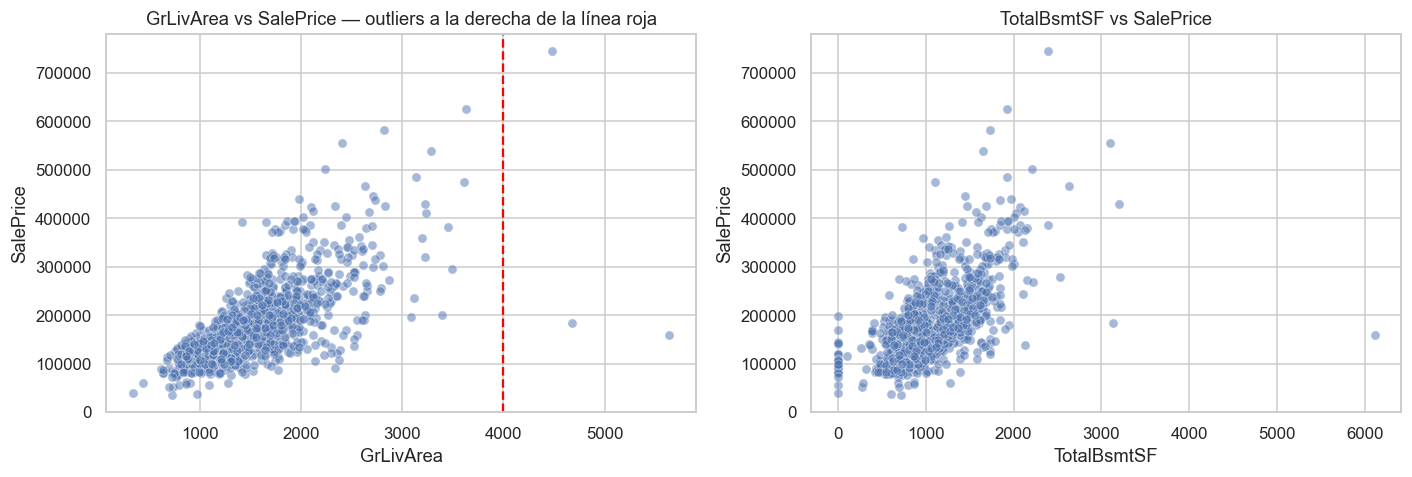

Outliers claros (GrLivArea>4000 y precio bajo): 2 filas -> Id [524, 1299]


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(x="GrLivArea", y=target, data=df, ax=ax[0], alpha=0.5)
ax[0].axvline(4000, color="red", ls="--")
ax[0].set_title("GrLivArea vs SalePrice — outliers a la derecha de la línea roja")

sns.scatterplot(x="TotalBsmtSF", y=target, data=df, ax=ax[1], alpha=0.5)
ax[1].set_title("TotalBsmtSF vs SalePrice")
plt.tight_layout(); plt.show()

outliers = df[(df["GrLivArea"] > 4000) & (df[target] < 300000)]
print(f"Outliers claros (GrLivArea>4000 y precio bajo): {len(outliers)} filas -> Id {outliers['Id'].tolist()}")

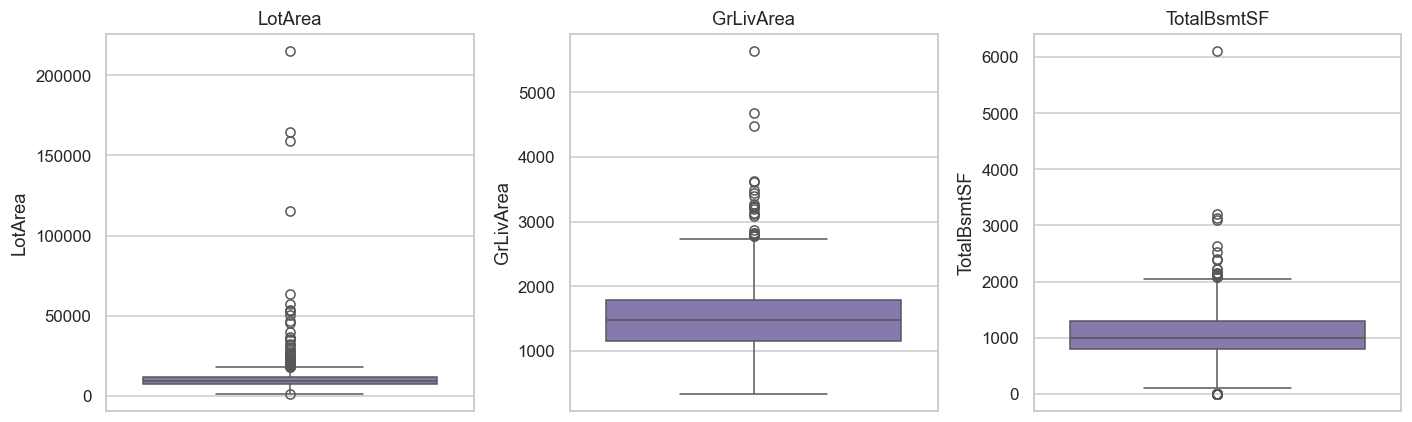

In [ ]:
# Boxplots para ver dispersión / atípicos
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for a, col in zip(axes, ["LotArea", "GrLivArea", "TotalBsmtSF"]):
    sns.boxplot(y=df[col], ax=a, color="#8172B3"); a.set_title(col)
plt.tight_layout(); plt.show()

**Decisión 2 — Outliers.** Eliminaremos las **pocas** filas con `GrLivArea > 4000` y precio
anormalmente bajo (recomendación del autor). No hacer poda agresiva por percentiles.

## 4. Visualizaciones: correlaciones y relación con el target

### 4.1 Matriz de correlación (numéricas)

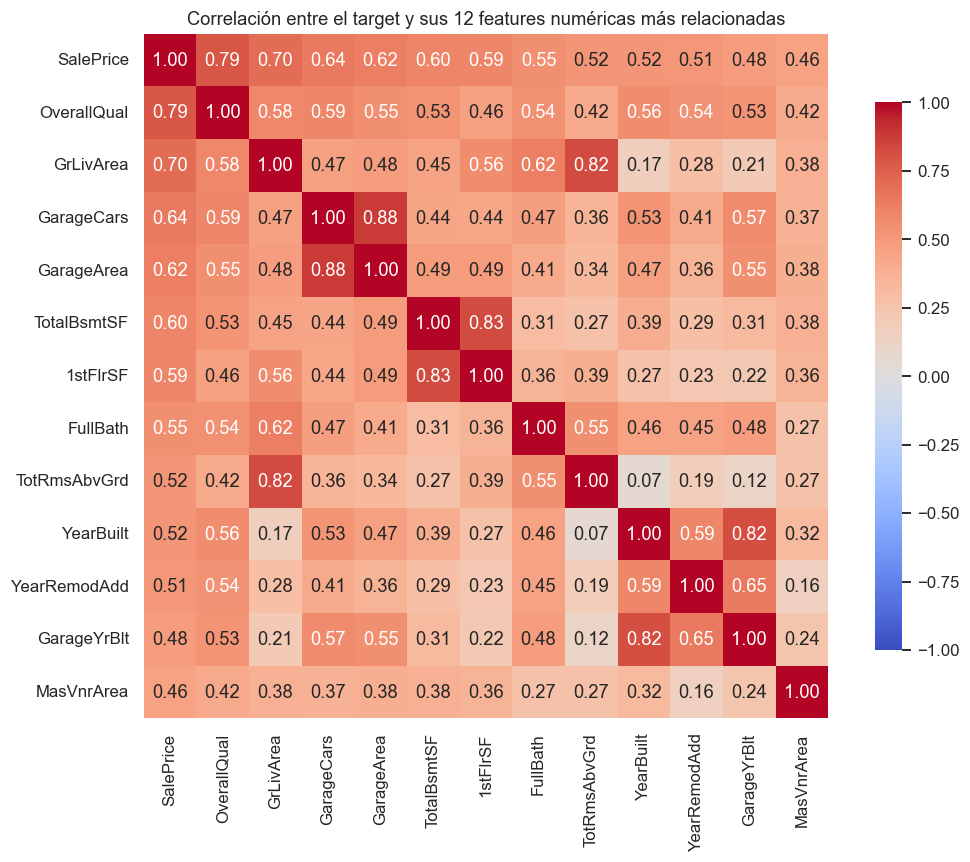

In [10]:
num_full = df.select_dtypes(include=[np.number]).drop(columns=[id_col])
corr = num_full.corr()

# Top variables más correlacionadas (en valor absoluto) con SalePrice
top = corr[target].abs().sort_values(ascending=False).head(13).index
plt.figure(figsize=(10, 8))
sns.heatmap(num_full[top].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})
plt.title("Correlación entre el target y sus 12 features numéricas más relacionadas")
plt.tight_layout(); plt.show()

In [11]:
corr_target = corr[target].sort_values(ascending=False)
print("=== Más correlacionadas (positivo) con SalePrice ===")
print(corr_target.head(11).round(3).to_string())
print("\n=== Más correlacionadas (negativo) ===")
print(corr_target.tail(5).round(3).to_string())

=== Más correlacionadas (positivo) con SalePrice ===
SalePrice       1.000
OverallQual     0.786
GrLivArea       0.696
GarageCars      0.641
GarageArea      0.624
TotalBsmtSF     0.598
1stFlrSF        0.588
FullBath        0.553
TotRmsAbvGrd    0.520
YearBuilt       0.517
YearRemodAdd    0.509

=== Más correlacionadas (negativo) ===
BsmtHalfBath    -0.048
OverallCond     -0.074
MSSubClass      -0.088
KitchenAbvGr    -0.143
EnclosedPorch   -0.150


**Observaciones de multicolinealidad**:
- `GarageCars` y `GarageArea` (r≈0.88), `TotalBsmtSF` y `1stFlrSF`, `GrLivArea` y `TotRmsAbvGrd`
  están muy correlacionadas entre sí. Un MLP tolera colinealidad (no requiere features
  independientes).

### 4.2 Relación de features clave con el target

/var/folders/ls/r_brwh_14l54j3kt17qt0xl80000gn/T/ipykernel_65433/2141373756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="OverallQual", y=target, data=df, ax=axes[0,0], palette="viridis")


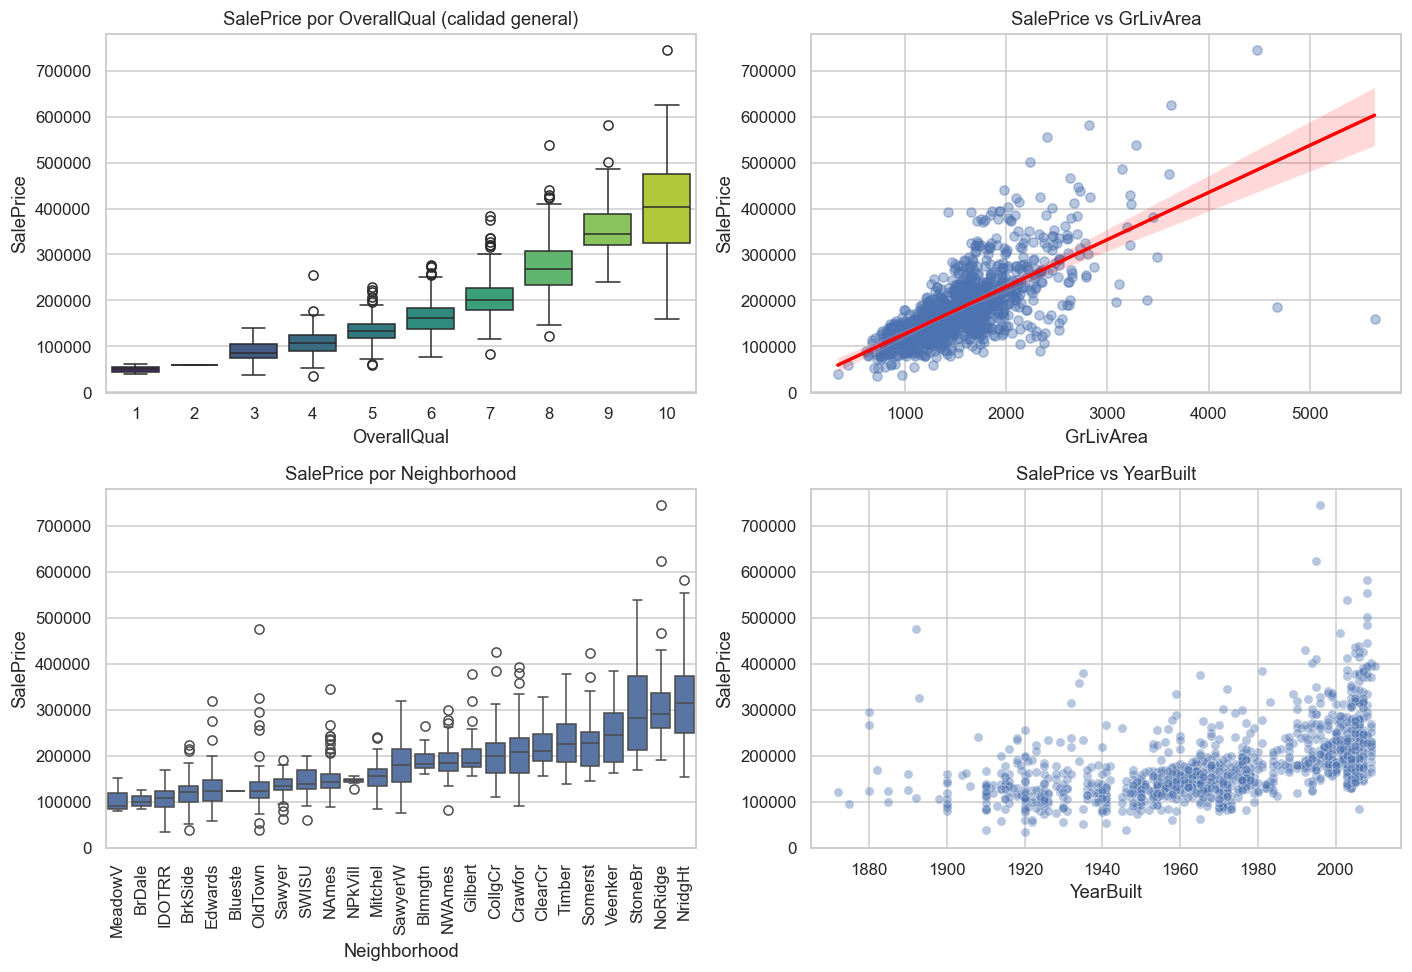

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
# OverallQual (ordinal) -> boxplot
sns.boxplot(x="OverallQual", y=target, data=df, ax=axes[0,0], palette="viridis")
axes[0,0].set_title("SalePrice por OverallQual (calidad general)")
# GrLivArea -> scatter con tendencia
sns.regplot(x="GrLivArea", y=target, data=df, ax=axes[0,1],
            scatter_kws={"alpha":0.4}, line_kws={"color":"red"})
axes[0,1].set_title("SalePrice vs GrLivArea")
# Neighborhood -> precio medio ordenado
order = df.groupby("Neighborhood")[target].median().sort_values().index
sns.boxplot(x="Neighborhood", y=target, data=df, order=order, ax=axes[1,0])
axes[1,0].set_title("SalePrice por Neighborhood"); axes[1,0].tick_params(axis="x", rotation=90)
# YearBuilt
sns.scatterplot(x="YearBuilt", y=target, data=df, ax=axes[1,1], alpha=0.4)
axes[1,1].set_title("SalePrice vs YearBuilt")
plt.tight_layout(); plt.show()

El precio crece de forma **monótona** con `OverallQual` y **lineal** con `GrLivArea`; el
`Neighborhood` separa claramente rangos de precio (feature categórica muy informativa); y las casas
más nuevas valen más. Todo esto confirma que las features tienen señal fuerte y bien estructurada.

### 4.3 Distribución y sesgo de las features numéricas

Varias features numéricas también están sesgadas. Para un MLP conviene reducir sesgos extremos
(mejora la escala de los gradientes). Lo tendremos en cuenta en el preprocesamiento.

In [13]:
skews = df[num_cols].skew().sort_values(ascending=False)
print("Features numéricas más sesgadas (|skew| alto):")
print(skews.head(10).round(2).to_string())

muy_sesgadas = skews[abs(skews) > 1].index.tolist()
print(f"\n# features con |skew|>1 candidatas a log1p: {len(muy_sesgadas)}")

Features numéricas más sesgadas (|skew| alto):
MiscVal          22.05
PoolArea         14.40
LotArea          11.96
3SsnPorch         9.83
LowQualFinSF      9.20
KitchenAbvGr      4.45
BsmtFinSF2        4.22
ScreenPorch       4.09
BsmtHalfBath      4.01
EnclosedPorch     3.16

# features con |skew|>1 candidatas a log1p: 19


### 4.4 Cardinalidad de las categóricas

Importa para decidir la codificación: one-hot en nominales de baja/media cardinalidad,
y codificación ordinal en las de calidad.

In [14]:
card = df[cat_cols].nunique().sort_values(ascending=False)
print("Cardinalidad de variables categóricas:")
print(card.to_string())
print(f"\nSi hiciéramos one-hot de TODAS: ~{sum(df[c].nunique() for c in cat_cols)} columnas dummy")

Cardinalidad de variables categóricas:
Neighborhood     25
Exterior2nd      16
Exterior1st      15
SaleType          9
Condition1        9
Condition2        8
HouseStyle        8
Functional        7
RoofMatl          7
BsmtFinType2      6
Heating           6
RoofStyle         6
SaleCondition     6
Foundation        6
GarageType        6
BsmtFinType1      6
HeatingQC         5
FireplaceQu       5
GarageQual        5
GarageCond        5
MSZoning          5
LotConfig         5
ExterCond         5
BldgType          5
KitchenQual       4
MiscFeature       4
Fence             4
LotShape          4
LandContour       4
BsmtCond          4
BsmtQual          4
Electrical        4
ExterQual         4
BsmtExposure      4
LandSlope         3
GarageFinish      3
MasVnrType        3
PavedDrive        3
PoolQC            3
Utilities         2
CentralAir        2
Alley             2
Street            2

Si hiciéramos one-hot de TODAS: ~249 columnas dummy
